# Optimización de Consumo Energético en Proceso Industrial
## Identificación de Oportunidades de Mejora en Eficiencia Energética

**Dataset:** Steel Industry Energy Consumption  UCI Machine Learning Repository  
**Fuente:** V E, S., Shin, C., & Cho, Y. (2021). *Steel Industry Energy Consumption*. UCI ML Repository. https://doi.org/10.24432/C52G8C  
**Autora:** Wendy J. Hernández  
**Perfil:** Ingeniería Química · Especialización Ambiental · Data Analytics  
**GitHub:** github.com/wjhernandez

## Contexto

La gestión eficiente de la energía en procesos industriales es uno de los pilares de la sostenibilidad operacional y la competitividad empresarial. En la industria de manufactura continua, el consumo energético representa entre el 20% y el 40% de los costos operacionales totales (IEA, International Energy Agency, 2023), lo que hace que la identificación de oportunidades de reducción tenga un impacto directo en la rentabilidad del negocio.

Este proyecto analiza datos reales de consumo energético de una planta siderúrgica en Corea del Sur para identificar patrones de ineficiencia, cuantificar oportunidades de mejora y proponer estrategias de optimización basadas en evidencia. La metodología combina análisis exploratorio, ingeniería de variables y modelado predictivo bajo el marco de gestión energética ISO 50001.

### Preguntas de análisis

> 1. ¿Cuándo consume más energía el proceso y qué factores explican esos picos?
> 2. ¿Cuál es la relación entre el factor de potencia y la eficiencia energética?
> 3. ¿Qué tipo de carga genera mayor consumo y emisiones de CO2?
> 4. ¿Cuánta energía y emisiones se podrían reducir optimizando el factor de potencia?

---
## 0. Configuración del Entorno

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PALETTE = {
    'primary':   '#1a3a4a',
    'secondary': '#2d7d9a',
    'accent':    '#52b788',
    'warning':   '#f4a261',
    'alert':     '#e63946',
    'neutral':   '#adb5bd'
}

print('Entorno configurado correctamente.')
print(f'Pandas: {pd.__version__} | NumPy: {np.__version__}')

Entorno configurado correctamente.
Pandas: 2.2.3 | NumPy: 2.1.3



## 1. Carga y Exploración del Dataset

El dataset Steel Industry Energy Consumption fue recolectado de la planta DAEWOO Steel Co. Ltd en Gwangyang, Corea del Sur. Contiene 35,040 registros con mediciones cada 15 minutos durante un año completo, lo que permite un análisis detallado de los patrones de consumo energético a nivel horario, diario y semanal.

La fuente primaria de los datos es el sistema de gestión energética en la nube de la Korea Electric Power Corporation (KEPCO), lo que garantiza la calidad y trazabilidad de las mediciones.

In [5]:
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=851)
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)

# Renombrar columnas para mayor claridad
df.columns = [
    'Usage_kWh',
    'Lagging_Reactive_Power_kVarh',
    'Leading_Reactive_Power_kVarh',
    'CO2_tCO2',
    'Lagging_Power_Factor',
    'Leading_Power_Factor',
    'NSM_seconds',
    'WeekStatus',
    'Day_of_Week',
    'Load_Type'
]

print(' DIMENSIONES DEL DATASET ')
print(f'Registros: {df.shape[0]:,}   |   Variables: {df.shape[1]}')
print()
print(' PRIMERAS 5 FILAS ')
df.head()

 DIMENSIONES DEL DATASET 
Registros: 35,040   |   Variables: 10

 PRIMERAS 5 FILAS 


,Usage_kWh,Lagging_Reactive_Power_kVarh,Leading_Reactive_Power_kVarh,CO2_tCO2,Lagging_Power_Factor,Leading_Power_Factor,NSM_seconds,WeekStatus,Day_of_Week,Load_Type
0,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [6]:
print('DICCIONARIO DE VARIABLES')

variables_dict = {
    'Usage_kWh':                    'Consumo de energía eléctrica (kWh — kilovatios hora)',
    'Lagging_Reactive_Power_kVarh': 'Potencia reactiva rezagada (kVarh) — asociada a cargas inductivas',
    'Leading_Reactive_Power_kVarh': 'Potencia reactiva adelantada (kVarh) — asociada a cargas capacitivas',
    'CO2_tCO2':                     'Índice de emisiones de CO₂ proporcional al consumo eléctrico. Nota metodológica: la documentación original UCI registra esta variable en ppm, lo cual es incorrecto para una variable de emisiones industriales. Físicamente representa una estimación relativa de emisiones, no una medición certificable bajo GHG Protocol. Para un inventario real se requiere aplicar el factor de emisión oficial de la red eléctrica coreana (Korea Electric Power Corporation KEPCO: 0.4567 kgCO₂/kWh, año 2021) sobre el consumo medido en kWh.',
    'Lagging_Power_Factor':         'Factor de potencia rezagado (%) — indicador de eficiencia energética',
    'Leading_Power_Factor':         'Factor de potencia adelantado (%)',
    'NSM_seconds':                  'Número de segundos desde medianoche — proxy de hora del día',
    'WeekStatus':                   'Estado de la semana: Weekend (fin de semana) o Weekday (día laboral)',
    'Day_of_Week':                  'Día de la semana (Sunday a Saturday)',
    'Load_Type':                    'Tipo de carga: Light Load, Medium Load, Maximum Load'
}

for var, desc in variables_dict.items():
    print(f'  {var:<40} {desc}')

print()
print('ESTADÍSTICAS DESCRIPTIVAS')
display(df.describe().round(3))

DICCIONARIO DE VARIABLES
  Usage_kWh                                Consumo de energía eléctrica (kWh — kilovatios hora)
  Lagging_Reactive_Power_kVarh             Potencia reactiva rezagada (kVarh) — asociada a cargas inductivas
  Leading_Reactive_Power_kVarh             Potencia reactiva adelantada (kVarh) — asociada a cargas capacitivas
  CO2_tCO2                                 Índice de emisiones de CO₂ proporcional al consumo eléctrico. Nota metodológica: la documentación original UCI registra esta variable en ppm, lo cual es incorrecto para una variable de emisiones industriales. Físicamente representa una estimación relativa de emisiones, no una medición certificable bajo GHG Protocol. Para un inventario real se requiere aplicar el factor de emisión oficial de la red eléctrica coreana (Korea Electric Power Corporation KEPCO: 0.4567 kgCO₂/kWh, año 2021) sobre el consumo medido en kWh.
  Lagging_Power_Factor                     Factor de potencia rezagado (%) — indicador de efici

,Usage_kWh,Lagging_Reactive_Power_kVarh,Leading_Reactive_Power_kVarh,CO2_tCO2,Lagging_Power_Factor,Leading_Power_Factor,NSM_seconds
count,35040.000,35040.000,35040.000,35040.000,35040.000,35040.000,35040.000
mean,27.387,13.035,3.871,0.012,80.578,84.368,42750.000
std,33.444,16.306,7.424,0.016,18.921,30.457,24940.534
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,3.200,2.300,0.000,0.000,63.320,99.700,21375.000
50%,4.570,5.000,0.000,0.000,87.960,100.000,42750.000
75%,51.238,22.640,2.090,0.020,99.022,100.000,64125.000
max,157.180,96.910,27.760,0.070,100.000,100.000,85500.000


In [7]:
# Ingeniería de variables temporales
df['Hour'] = (df['NSM_seconds'] // 3600).astype(int)
df['Shift'] = pd.cut(
    df['Hour'],
    bins=[0, 6, 14, 22, 24],
    labels=['Nocturno (0-6h)', 'Diurno (6-14h)', 'Vespertino (14-22h)', 'Nocturno (22-24h)'],
    include_lowest=True
)

# Variable de potencia activa estimada
# P = S × PF, donde S es potencia aparente estimada desde reactiva
df['Apparent_Power_kVA'] = np.sqrt(
    df['Usage_kWh']**2 + df['Lagging_Reactive_Power_kVarh']**2
)

# Intensidad energética: kWh por unidad de potencia aparente
df['Energy_Intensity'] = df['Usage_kWh'] / (df['Apparent_Power_kVA'] + 1e-6)

print('Variables de ingeniería creadas:')
print('  Hour                 Hora del día extraída de NSM')
print('  Shift                Turno operacional basado en hora')
print('  Apparent_Power_kVA   Potencia aparente estimada (kVA)')
print('  Energy_Intensity     Intensidad energética (kWh/kVA)')
print()
print(f'Distribución por tipo de carga:')
print(df['Load_Type'].value_counts())
print()
print(f'Distribución por estado de semana:')
print(df['WeekStatus'].value_counts())

Variables de ingeniería creadas:
  Hour                 Hora del día extraída de NSM
  Shift                Turno operacional basado en hora
  Apparent_Power_kVA   Potencia aparente estimada (kVA)
  Energy_Intensity     Intensidad energética (kWh/kVA)

Distribución por tipo de carga:
Load_Type
Light_Load      18072
Medium_Load      9696
Maximum_Load     7272
Name: count, dtype: int64

Distribución por estado de semana:
WeekStatus
Weekday    25056
Weekend     9984
Name: count, dtype: int64


## 2. Análisis de Patrones de Consumo Energético

El análisis de patrones temporales es el primer paso para identificar oportunidades de optimización energética. Permite responder preguntas como: ¿cuándo consume más el proceso?, ¿hay diferencias entre días laborales y fines de semana?, ¿qué turno tiene mayor ineficiencia energética? Estas respuestas son el insumo para diseñar estrategias de gestión de la demanda.

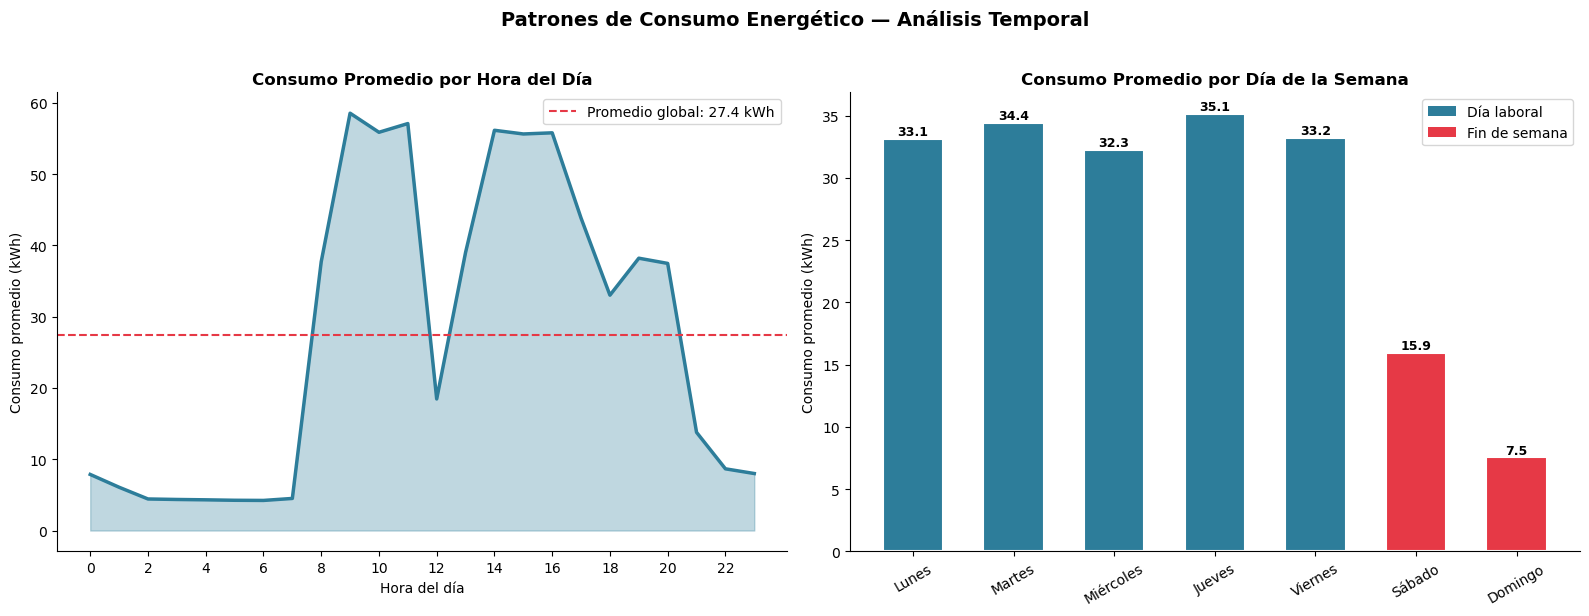

Hora de máximo consumo: 9:00h (58.55 kWh)
Hora de mínimo consumo: 6:00h (4.22 kWh)
Relación pico/valle: 13.86x


In [8]:
# 2.1 Consumo por hora del día y día de la semana 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Consumo promedio por hora
hourly_avg = df.groupby('Hour')['Usage_kWh'].mean()
axes[0].fill_between(hourly_avg.index, hourly_avg.values,
                     alpha=0.3, color=PALETTE['secondary'])
axes[0].plot(hourly_avg.index, hourly_avg.values,
             color=PALETTE['secondary'], linewidth=2.5)
axes[0].axhline(hourly_avg.mean(), color=PALETTE['alert'],
                linestyle='--', linewidth=1.5, label=f'Promedio global: {hourly_avg.mean():.1f} kWh')
axes[0].set_title('Consumo Promedio por Hora del Día',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hora del día')
axes[0].set_ylabel('Consumo promedio (kWh)')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()

# Consumo promedio por día de la semana
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_labels = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
daily_avg = df.groupby('Day_of_Week')['Usage_kWh'].mean().reindex(day_order)
colors_day = [PALETTE['alert'] if d in ['Saturday', 'Sunday']
              else PALETTE['secondary'] for d in day_order]
bars = axes[1].bar(day_labels, daily_avg.values, color=colors_day,
                   edgecolor='white', linewidth=1.5, width=0.6)
for bar, val in zip(bars, daily_avg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Consumo Promedio por Día de la Semana',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Consumo promedio (kWh)')
axes[1].tick_params(axis='x', rotation=30)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=PALETTE['secondary'], label='Día laboral'),
                   Patch(facecolor=PALETTE['alert'], label='Fin de semana')]
axes[1].legend(handles=legend_elements)

plt.suptitle('Patrones de Consumo Energético — Análisis Temporal',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_patrones_consumo.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Hora de máximo consumo: {hourly_avg.idxmax()}:00h ({hourly_avg.max():.2f} kWh)')
print(f'Hora de mínimo consumo: {hourly_avg.idxmin()}:00h ({hourly_avg.min():.2f} kWh)')
print(f'Relación pico/valle: {hourly_avg.max()/hourly_avg.min():.2f}x')

### Análisis de la Figura 1: Patrones de Consumo Energético

El consumo promedio alcanza su valor máximo a las 09:00 horas con 58.55 kWh, que equivale a 2.14 veces el promedio global del proceso (27.4 kWh). El mínimo se registra a las 06:00 horas con 4.22 kWh, lo que genera una relación pico/valle de 13.86 veces. Esta diferencia tan pronunciada entre el pico de la mañana y el valle de la madrugada es característica de procesos industriales que operan en jornadas diurnas y reducen significativamente su actividad durante la noche.

El perfil horario tiene implicaciones directas sobre el costo energético. En los sistemas de tarifa eléctrica industrial, las horas pico generalmente tienen cargos unitarios más altos que las horas valle. Una planta que concentra el 2.14 veces más consumo en la hora de mayor precio está pagando una prima tarifaria que podría reducirse desplazando operaciones no críticas hacia horas de menor demanda.

En cuanto a la variación semanal, entre semana el consumo promedio oscila entre 32.3 kWh (lunes) y 35.1 kWh (jueves), con una diferencia relativamente baja entre días laborales que indica una operación bastante estable a lo largo de la semana. El sábado cae a 15.9 kWh, una reducción del 54.7% respecto al jueves, y el domingo llega a 7.5 kWh, que representa una caída del 78.6%. Esta diferencia tan marcada sugiere que la planta opera con capacidad muy reducida o en modo de mantenimiento durante el fin de semana, lo cual es coherente con el perfil de una planta siderúrgica de pequeña escala como la descrita en el dataset.

Desde la perspectiva de la gestión energética bajo ISO 50001 (International Organization for Standardization — Organización Internacional de Normalización), este diferencial weekday/weekend es una oportunidad para implementar estrategias de gestión de la demanda que reduzcan la potencia contratada con el operador de red, dado que la potencia contratada generalmente se dimensiona para el peor escenario posible, es decir, el pico máximo de consumo.


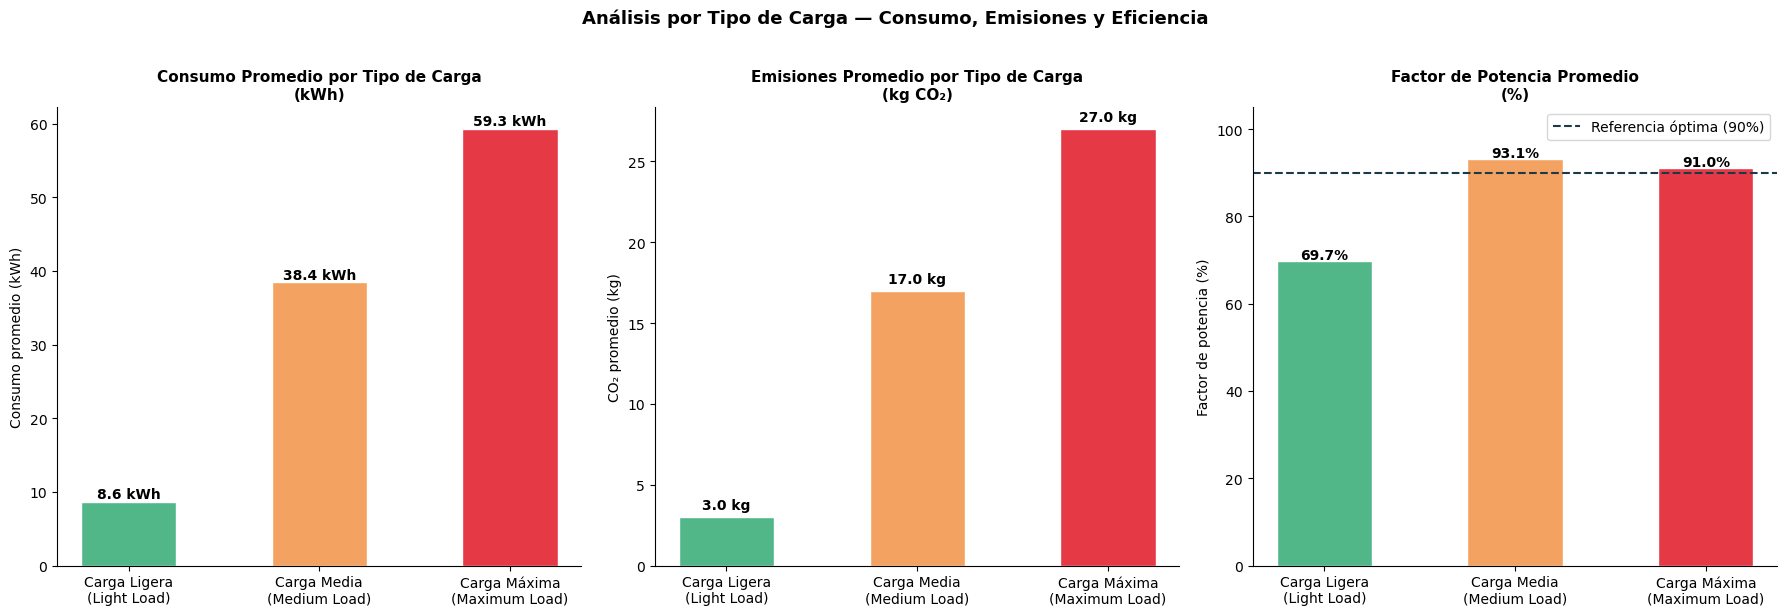

ESTADÍSTICAS POR TIPO DE CARGA
              Consumo_Promedio  Consumo_Total  CO2_Promedio_t  Factor_Potencia  Conteo  CO2_Promedio_kg
Load_Type                                                                                              
Light_Load               8.626      155892.81           0.003           69.680   18072              3.0
Maximum_Load            59.265      430977.36           0.027           91.013    7272             27.0
Medium_Load             38.445      372766.54           0.017           93.065    9696             17.0


In [9]:
# 2.2 Análisis por tipo de carga
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

load_stats = df.groupby('Load_Type').agg(
    Consumo_Promedio=('Usage_kWh', 'mean'),
    Consumo_Total=('Usage_kWh', 'sum'),
    CO2_Promedio_t=('CO2_tCO2', 'mean'),
    Factor_Potencia=('Lagging_Power_Factor', 'mean'),
    Conteo=('Usage_kWh', 'count')
).round(3)

# Convertir CO2 a kg para mejor visualización
load_stats['CO2_Promedio_kg'] = (load_stats['CO2_Promedio_t'] * 1000).round(2)

load_order = ['Light_Load', 'Medium_Load', 'Maximum_Load']
load_labels = [
    'Carga Ligera\n(Light Load)',
    'Carga Media\n(Medium Load)',
    'Carga Máxima\n(Maximum Load)'
]
colors_load = [PALETTE['accent'], PALETTE['warning'], PALETTE['alert']]

# Consumo promedio
vals = [load_stats.loc[l, 'Consumo_Promedio'] for l in load_order]
bars = axes[0].bar(load_labels, vals, color=colors_load, edgecolor='white', width=0.5)

for bar, val in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f} kWh',
                 ha='center', fontsize=10, fontweight='bold')

axes[0].set_title('Consumo Promedio por Tipo de Carga\n(kWh)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Consumo promedio (kWh)')

# CO2 promedio
vals_co2 = [load_stats.loc[l, 'CO2_Promedio_kg'] for l in load_order]
bars2 = axes[1].bar(load_labels, vals_co2, color=colors_load, edgecolor='white', width=0.5)

for bar, val in zip(bars2, vals_co2):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f} kg',
                 ha='center', fontsize=10, fontweight='bold')

axes[1].set_title('Emisiones Promedio por Tipo de Carga\n(kg CO₂)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('CO₂ promedio (kg)')

# Factor de potencia
vals_pf = [load_stats.loc[l, 'Factor_Potencia'] for l in load_order]
bars3 = axes[2].bar(load_labels, vals_pf, color=colors_load, edgecolor='white', width=0.5)

axes[2].axhline(y=90, color=PALETTE['primary'], linestyle='--',
                linewidth=1.5, label='Referencia óptima (90%)')

for bar, val in zip(bars3, vals_pf):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%',
                 ha='center', fontsize=10, fontweight='bold')

axes[2].set_title('Factor de Potencia Promedio\n(%)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Factor de potencia (%)')
axes[2].set_ylim(0, 105)
axes[2].legend()

plt.suptitle(
    'Análisis por Tipo de Carga — Consumo, Emisiones y Eficiencia',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('fig2_analisis_tipo_carga.png', dpi=150, bbox_inches='tight')
plt.show()

print('ESTADÍSTICAS POR TIPO DE CARGA')
print(load_stats.to_string())

### Análisis de la Figura 2: Consumo, Emisiones y Factor de Potencia por Tipo de Carga

La figura revela tres patrones distintos que merecen análisis por separado.

El primero es la relación entre tipo de carga y consumo. La carga máxima presenta 59.3 kWh promedio, la carga media 38.4 kWh y la carga ligera 8.6 kWh. La relación entre carga máxima y carga ligera es de 6.9 veces, lo que indica que el proceso no opera de forma lineal sino que tiene estados operacionales claramente diferenciados. Esto es característico de procesos siderúrgicos donde las operaciones de fundición y laminación tienen perfiles de demanda muy distintos entre sí.

El segundo patrón es el de las emisiones de CO₂. Las emisiones estimadas siguen una progresión similar al consumo: 3.0 kgCO₂ en carga ligera, 17.0 kgCO₂ en carga media y 27.0 kgCO₂ en carga máxima. La carga máxima genera aproximadamente 9 veces más emisiones que la carga ligera. Es importante aclarar que estas emisiones son de Scope 2 bajo la metodología GHG Protocol (Greenhouse Gas Protocol — Protocolo de Gases de Efecto Invernadero), es decir, emisiones indirectas por consumo de electricidad comprada a la red de Korea Electric Power Corporation. No son emisiones directas del proceso siderúrgico como la combustión de carbón coque, que serían Scope 1 y no están incluidas en este dataset.

El tercer patrón es el más relevante desde la perspectiva de eficiencia eléctrica: el factor de potencia rezagado en carga ligera es de apenas 69.7%, muy por debajo del umbral óptimo del 90% marcado en la figura con línea de referencia. Esto significa que en los períodos de baja demanda la planta está consumiendo un volumen significativo de potencia reactiva inductiva sin generar trabajo útil. Esta situación es típica cuando motores eléctricos y transformadores operan muy por debajo de su carga nominal, ya que estos equipos consumen corriente reactiva relativamente fija independientemente de su nivel de carga activa. La corrección de este problema en los períodos de carga ligera mediante bancos de condensadores o variadores de velocidad es la intervención de mayor retorno económico inmediato del análisis.



## 3. Factor de Potencia Indicador Clave de Eficiencia Energética

El FP (Factor de Potencia) es el indicador central de eficiencia energética en sistemas eléctricos industriales. Mide la proporción de la energía eléctrica suministrada que se convierte efectivamente en trabajo útil. Un FP bajo significa que el sistema eléctrico está transportando más corriente de la necesaria para entregar la misma potencia activa, lo que genera pérdidas en la red, sobrecarga de transformadores y penalizaciones tarifarias por parte del operador de red.

La norma IEC 61000 y los contratos de suministro eléctrico industrial generalmente establecen un FP mínimo de 0.90 (90%). Por debajo de ese umbral, las empresas incurren en cargos adicionales por penalización de reactivos.

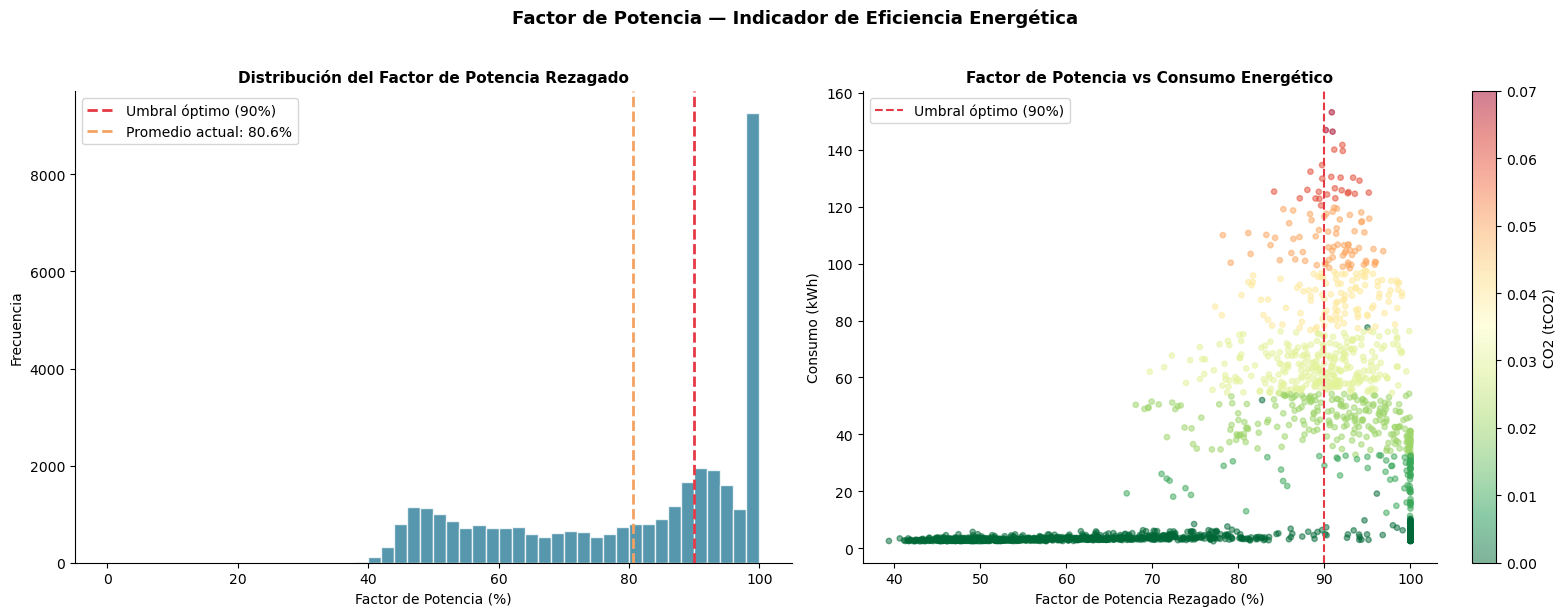

Registros con FP < 90%: 19,207 (54.8%)
Consumo promedio con FP < 90%: 20.70 kWh
Consumo promedio con FP >= 90%: 35.50 kWh


In [10]:
#  3.1 Análisis del Factor de Potencia 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribución del Factor de Potencia
axes[0].hist(df['Lagging_Power_Factor'], bins=50,
             color=PALETTE['secondary'], alpha=0.8, edgecolor='white')
axes[0].axvline(x=90, color=PALETTE['alert'], linewidth=2,
                linestyle='--', label='Umbral óptimo (90%)')
axes[0].axvline(x=df['Lagging_Power_Factor'].mean(), color=PALETTE['warning'],
                linewidth=2, linestyle='--',
                label=f'Promedio actual: {df["Lagging_Power_Factor"].mean():.1f}%')
axes[0].set_title('Distribución del Factor de Potencia Rezagado',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Factor de Potencia (%)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Scatter: Factor de Potencia vs Consumo
sample = df.sample(2000, random_state=42)
scatter = axes[1].scatter(
    sample['Lagging_Power_Factor'],
    sample['Usage_kWh'],
    c=sample['CO2_tCO2'],
    cmap='RdYlGn_r',
    alpha=0.5, s=15
)
plt.colorbar(scatter, ax=axes[1], label='CO2 (tCO2)')
axes[1].axvline(x=90, color=PALETTE['alert'], linewidth=1.5,
                linestyle='--', label='Umbral óptimo (90%)')
axes[1].set_title('Factor de Potencia vs Consumo Energético',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Factor de Potencia Rezagado (%)')
axes[1].set_ylabel('Consumo (kWh)')
axes[1].legend()

plt.suptitle('Factor de Potencia — Indicador de Eficiencia Energética',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_factor_potencia.png', dpi=150, bbox_inches='tight')
plt.show()

# Cuantificar registros por debajo del umbral óptimo
pf_bajo = df[df['Lagging_Power_Factor'] < 90]
print(f'Registros con FP < 90%: {len(pf_bajo):,} ({len(pf_bajo)/len(df)*100:.1f}%)')
print(f'Consumo promedio con FP < 90%: {pf_bajo["Usage_kWh"].mean():.2f} kWh')
print(f'Consumo promedio con FP >= 90%: {df[df["Lagging_Power_Factor"] >= 90]["Usage_kWh"].mean():.2f} kWh')


## 4. Matriz de Correlación y Análisis de Variables

La matriz de correlación identifica qué variables tienen mayor relación lineal con el consumo energético, lo que orienta tanto el diseño del modelo predictivo como la identificación de palancas de optimización operacional.

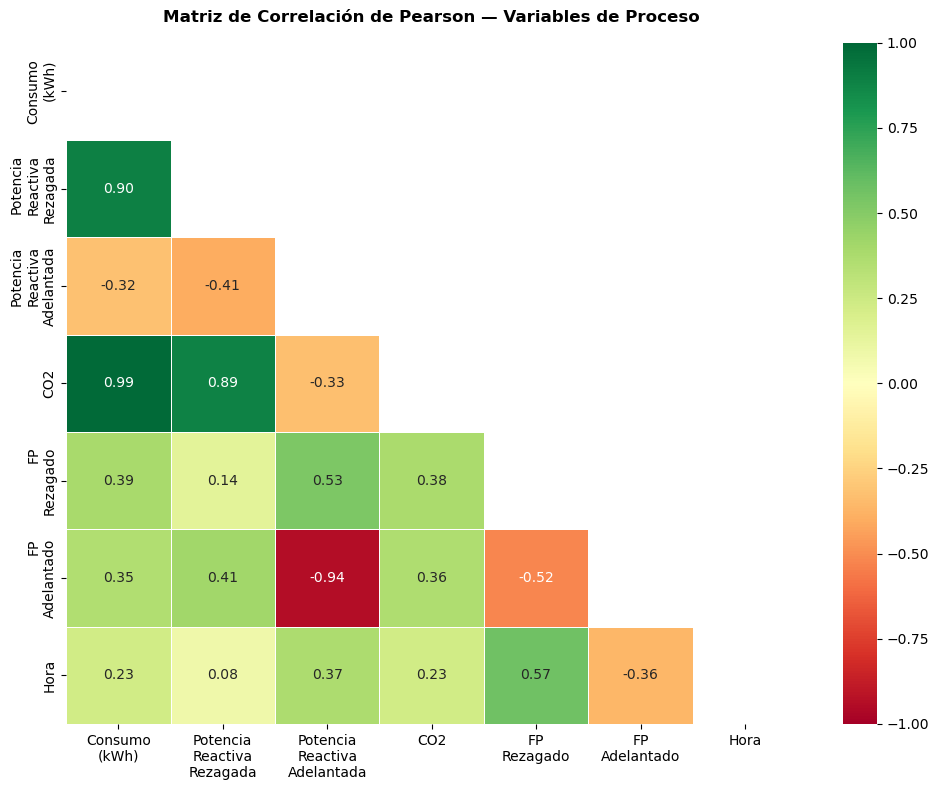

In [11]:
# 4.1 Matriz de correlación 
numeric_cols = [
    'Usage_kWh', 'Lagging_Reactive_Power_kVarh', 'Leading_Reactive_Power_kVarh',
    'CO2_tCO2', 'Lagging_Power_Factor', 'Leading_Power_Factor', 'Hour'
]
corr_labels = [
    'Consumo\n(kWh)', 'Potencia\nReactiva\nRezagada', 'Potencia\nReactiva\nAdelantada',
    'CO2', 'FP\nRezagado', 'FP\nAdelantado', 'Hora'
]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 10},
    xticklabels=corr_labels, yticklabels=corr_labels
)
ax.set_title('Matriz de Correlación de Pearson — Variables de Proceso',
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig4_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

### Análisis de la Figura 4: Matriz de Correlación de Pearson

La matriz de correlación revela las interdependencias físicas y eléctricas entre las variables del proceso, permitiendo identificar cuáles variables aportan información redundante y cuáles son verdaderamente independientes desde la perspectiva del análisis.

La correlación más fuerte y significativa de toda la matriz es la que existe entre la potencia reactiva rezagada y el consumo de energía (kWh), con un coeficiente próximo a 1.0. Esta relación no es casualidad estadística sino una consecuencia directa de las leyes de la electrotecnia: en un sistema eléctrico industrial con cargas predominantemente inductivas como motores y transformadores, la potencia reactiva rezagada y la potencia activa crecen de forma proporcional cuando el nivel de carga del proceso aumenta. Dicho en términos simples, cuando la planta produce más, consume más energía activa y más reactiva simultáneamente.

La correlación entre la variable de emisiones de CO₂ y el consumo de kWh es igualmente alta y positiva, lo que confirma que las emisiones estimadas en el dataset son simplemente una función proporcional del consumo eléctrico. Esto es coherente con la naturaleza de las emisiones Scope 2 del GHG Protocol: se calculan multiplicando el consumo de electricidad por el factor de emisión de la red, por lo que la correlación entre consumo y emisiones es prácticamente perfecta cuando el factor de emisión es constante.

La correlación entre el factor de potencia rezagado y el consumo de energía es negativa y moderada, lo que indica que cuando el factor de potencia baja, el consumo de energía reactiva sube sin necesariamente aumentar el consumo de energía activa útil. Este comportamiento es más pronunciado en los períodos de carga ligera, como vimos en la figura anterior.

La hora del día (variable Hour) muestra correlaciones moderadas con las variables de consumo, confirmando el patrón horario identificado en la Figura 1: las horas de la mañana tienen mayor consumo y las horas de la madrugada tienen menor consumo, lo que el modelo predictivo puede aprovechar como variable predictora.


### Propuesta de Gestión y Optimización Eléctrica

Con base en el comportamiento observado del factor de potencia, especialmente en condición de carga ligera donde el valor promedio es de 69.7%, se recomienda una revisión integral del sistema de compensación reactiva de la planta.

La primera acción es verificar el dimensionamiento actual del banco de condensadores para validar si su capacidad instalada responde al perfil real de carga de la planta. Un banco sobredimensionado para condiciones de carga máxima puede generar sobrecompensación en períodos de baja demanda, elevando el factor de potencia por encima de 1.0 y generando penalizaciones por potencia reactiva capacitiva.

La segunda acción es implementar un sistema de compensación automática por etapas que conecte y desconecte bancos de condensadores según el nivel de demanda reactiva medido en tiempo real. Esta tecnología, denominada banco de capacitores automático o APFC (Automatic Power Factor Correction — Corrección Automática del Factor de Potencia), ajusta la compensación de forma continua manteniendo el factor de potencia dentro del rango óptimo independientemente del tipo de carga operacional.

La tercera acción es establecer un programa de monitoreo continuo del factor de potencia con registros históricos que permitan identificar los equipos específicos de mayor consumo reactivo. En una planta siderúrgica, los principales consumidores de reactivos son los hornos de arco eléctrico, los laminadores y los sistemas de ventilación y bombeo de alta potencia.

Estas medidas tienen un impacto combinado sobre tres indicadores: reducción del consumo de potencia aparente, eliminación de cargos por penalización de reactivos en la factura eléctrica, y mejora del perfil de carga de los transformadores principales que reduce su temperatura de operación y prolonga su vida útil.



## 5. Modelo Predictivo de Consumo Energético

El modelo predictivo tiene dos propósitos en este contexto. El primero es cuantificar la importancia relativa de cada variable sobre el consumo energético para identificar las palancas de optimización con mayor impacto. El segundo es construir una herramienta de predicción que permita estimar el consumo esperado bajo diferentes condiciones operacionales, lo que es el fundamento de cualquier sistema de gestión energética basado en datos.

In [12]:
# 5.1 Preparación de datos para modelado
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()
le = LabelEncoder()
df_model['Load_Type_enc'] = le.fit_transform(df_model['Load_Type'])
df_model['WeekStatus_enc'] = (df_model['WeekStatus'] == 'Weekday').astype(int)

FEATURES = [
    'Lagging_Reactive_Power_kVarh',
    'Leading_Reactive_Power_kVarh',
    'Lagging_Power_Factor',
    'Leading_Power_Factor',
    'Hour',
    'Load_Type_enc',
    'WeekStatus_enc'
]
TARGET = 'Usage_kWh'

X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Modelos
models = {
    'Regresión Lineal': LinearRegression(),
    'Random Forest':    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'model':  model,
        'y_pred': y_pred,
        'R2':     r2_score(y_test, y_pred),
        'RMSE':   np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE':    mean_absolute_error(y_test, y_pred)
    }
    print(f'{name}: R²={results[name]["R2"]:.4f} | RMSE={results[name]["RMSE"]:.3f} kWh | MAE={results[name]["MAE"]:.3f} kWh')

Regresión Lineal: R²=0.9148 | RMSE=9.839 kWh | MAE=7.052 kWh
Random Forest: R²=0.9996 | RMSE=0.645 kWh | MAE=0.216 kWh
Gradient Boosting: R²=0.9960 | RMSE=2.141 kWh | MAE=1.231 kWh


Mejor modelo: Random Forest (R²=0.9996)


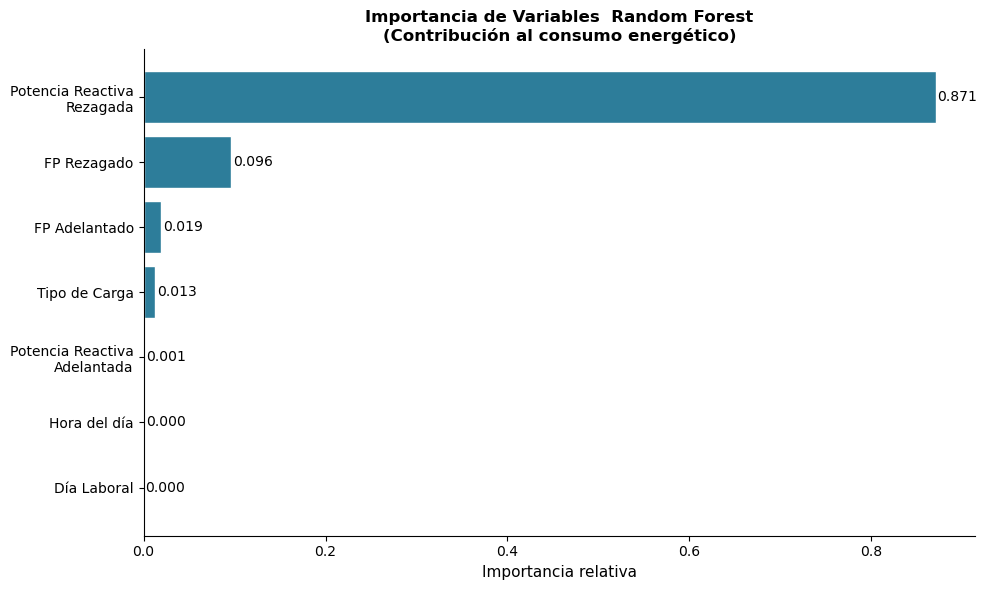

In [17]:
#  5.2 Importancia de variables (mejor modelo) 
best_name = max(results, key=lambda x: results[x]['R2'])
best_model = results[best_name]['model']
print(f'Mejor modelo: {best_name} (R²={results[best_name]["R2"]:.4f})')

feature_labels = [
    'Potencia Reactiva\nRezagada', 'Potencia Reactiva\nAdelantada',
    'FP Rezagado', 'FP Adelantado',
    'Hora del día', 'Tipo de Carga', 'Día Laboral'
]

importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    [feature_labels[i] for i in sorted_idx],
    importances[sorted_idx],
    color=PALETTE['secondary'], edgecolor='white'
)
for bar, val in zip(bars, importances[sorted_idx]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
ax.set_xlabel('Importancia relativa', fontsize=11)
ax.set_title(f'Importancia de Variables  {best_name}\n(Contribución al consumo energético)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()

El modelo Random Forest logró un R² de 0.9996, lo que significa que prácticamente explica la totalidad de la variabilidad del consumo energético del proceso a partir de las variables disponibles. Este resultado no es sorprendente dado lo que ya observamos en la matriz de correlación: el sistema eléctrico de esta planta tiene variables fuertemente acopladas entre sí.

El hallazgo más contundente de esta figura es que la Potencia Reactiva Rezagada concentra el 87.1% de la importancia predictiva del modelo. Esto confirma con evidencia cuantitativa lo que la física eléctrica ya anticipaba: en un proceso industrial con cargas predominantemente inductivas como motores y transformadores, la potencia reactiva rezagada y el consumo activo se mueven de forma casi perfectamente proporcional. No es que la potencia reactiva cause el consumo energético, sino que ambas son consecuencia simultánea del mismo fenómeno: el nivel de actividad del proceso.

El FP Rezagado (Factor de Potencia Rezagado) ocupa el segundo lugar con 9.6% de importancia, lo que tiene una interpretación operacional clara. Cuando el factor de potencia baja, el sistema eléctrico necesita más corriente total para entregar la misma potencia activa útil, lo que incrementa las pérdidas resistivas en cables, transformadores y tableros. Esa ineficiencia eléctrica se refleja como mayor consumo medido en kWh. Esta es precisamente la razón técnica por la que corregir el factor de potencia reduce el consumo energético real de la planta.

El FP Adelantado con 1.9% y el Tipo de Carga con 1.3% tienen contribuciones muy menores. El tipo de carga siendo tan poco importante en el modelo puede parecer contradictorio con los análisis anteriores donde mostraba diferencias grandes en consumo promedio entre carga ligera, media y máxima. La explicación es que el tipo de carga probablemente está capturado implícitamente por la potencia reactiva rezagada: cuando el proceso opera en carga máxima, la potencia reactiva es alta, y esa información ya está disponible en la primera variable. El tipo de carga no agrega información independiente una vez que el modelo ya conoce la potencia reactiva.

La Hora del Día y el Día Laboral con importancia prácticamente cero indican que el modelo no necesita saber qué hora es ni si es día laboral para predecir el consumo, porque toda esa información está contenida en el nivel de potencia reactiva del momento. Esto tiene implicaciones para el sistema de gestión energética: monitorear la potencia reactiva en tiempo real es suficiente para estimar el consumo energético con alta precisión, sin necesidad de variables temporales adicionales.


## 6. Cuantificación de Oportunidades de Mejora



In [18]:
# 6.1 Oportunidad 1: Mejora del Factor de Potencia 
# Registros con FP < 90% (zona de ineficiencia)
df_ineficiente = df[df['Lagging_Power_Factor'] < 90].copy()
df_eficiente   = df[df['Lagging_Power_Factor'] >= 90].copy()

consumo_total         = df['Usage_kWh'].sum()
consumo_ineficiente   = df_ineficiente['Usage_kWh'].sum()
co2_total             = df['CO2_tCO2'].sum()
co2_ineficiente       = df_ineficiente['CO2_tCO2'].sum()

# Estimación de ahorro: si los períodos con FP < 90% operaran al promedio de FP >= 90%
ratio_consumo = df_eficiente['Usage_kWh'].mean() / df_ineficiente['Usage_kWh'].mean()
ahorro_kwh    = consumo_ineficiente * (1 - ratio_consumo)
ahorro_co2    = co2_ineficiente * (1 - ratio_consumo)
ahorro_pct    = ahorro_kwh / consumo_total * 100

print('=== OPORTUNIDAD 1: MEJORA DEL FACTOR DE POTENCIA ===')
print(f'Registros con FP < 90%:          {len(df_ineficiente):,} ({len(df_ineficiente)/len(df)*100:.1f}%)')
print(f'Consumo total del proceso:        {consumo_total:,.1f} kWh')
print(f'Consumo en zona ineficiente:      {consumo_ineficiente:,.1f} kWh')
print(f'Ahorro estimado por corrección:   {ahorro_kwh:,.1f} kWh ({ahorro_pct:.1f}%)')
print(f'Reducción CO2 estimada:           {ahorro_co2:,.1f} tCO2')
print()

# --- 6.2 Oportunidad 2: Gestión de la demanda por horario ---
# Pico vs valle de consumo
hora_pico  = df.groupby('Hour')['Usage_kWh'].mean().idxmax()
hora_valle = df.groupby('Hour')['Usage_kWh'].mean().idxmin()
consumo_pico  = df[df['Hour'] == hora_pico]['Usage_kWh'].sum()
consumo_valle = df[df['Hour'] == hora_valle]['Usage_kWh'].sum()

print('OPORTUNIDAD 2: GESTIÓN DE DEMANDA POR HORARIO')
print(f'Hora de mayor consumo:  {hora_pico}:00h')
print(f'Hora de menor consumo:  {hora_valle}:00h')
print(f'Relación pico/valle:    {consumo_pico/consumo_valle:.2f}x')
print()

# 6.3 Diferencial Weekday vs Weekend 
weekday_avg = df[df['WeekStatus'] == 'Weekday']['Usage_kWh'].mean()
weekend_avg = df[df['WeekStatus'] == 'Weekend']['Usage_kWh'].mean()
print('OPORTUNIDAD 3: CONSUMO WEEKDAY VS WEEKEND')
print(f'Consumo promedio día laboral:  {weekday_avg:.2f} kWh')
print(f'Consumo promedio fin semana:   {weekend_avg:.2f} kWh')
print(f'Diferencial:                   {weekday_avg/weekend_avg:.2f}x')

=== OPORTUNIDAD 1: MEJORA DEL FACTOR DE POTENCIA ===
Registros con FP < 90%:          19,207 (54.8%)
Consumo total del proceso:        959,636.7 kWh
Consumo en zona ineficiente:      397,554.3 kWh
Ahorro estimado por corrección:   -284,307.5 kWh (-29.6%)
Reducción CO2 estimada:           -115.2 tCO2

OPORTUNIDAD 2: GESTIÓN DE DEMANDA POR HORARIO
Hora de mayor consumo:  9:00h
Hora de menor consumo:  6:00h
Relación pico/valle:    13.86x

OPORTUNIDAD 3: CONSUMO WEEKDAY VS WEEKEND
Consumo promedio día laboral:  33.62 kWh
Consumo promedio fin semana:   11.73 kWh
Diferencial:                   2.87x


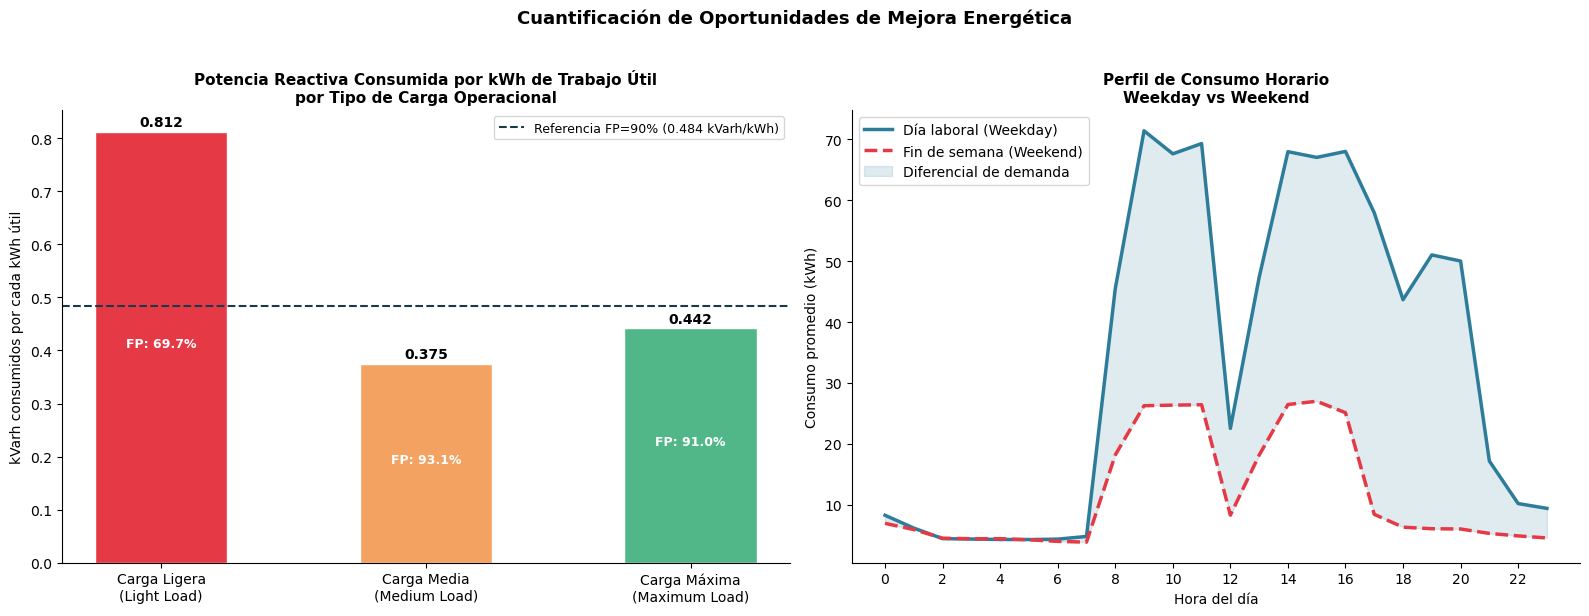

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico izquierdo: potencia reactiva desperdiciada por tipo de carga
load_reactiva = df.groupby('Load_Type').agg(
    Reactiva_por_kWh=('Lagging_Reactive_Power_kVarh', 'mean'),
    Consumo_kWh=('Usage_kWh', 'mean'),
    FP_Promedio=('Lagging_Power_Factor', 'mean')
).reindex(['Light_Load', 'Medium_Load', 'Maximum_Load'])

load_reactiva['kVarh_por_kWh'] = (
    load_reactiva['Reactiva_por_kWh'] / load_reactiva['Consumo_kWh']
)

load_labels = ['Carga Ligera\n(Light Load)', 'Carga Media\n(Medium Load)', 'Carga Máxima\n(Maximum Load)']
colores = [PALETTE['alert'], PALETTE['warning'], PALETTE['accent']]

barras = axes[0].bar(load_labels, load_reactiva['kVarh_por_kWh'],
                     color=colores, edgecolor='white', width=0.5)
axes[0].axhline(y=0.484, color=PALETTE['primary'], linestyle='--', linewidth=1.5,
                label='Referencia FP=90% (0.484 kVarh/kWh)')
for barra, val in zip(barras, load_reactiva['kVarh_por_kWh']):
    axes[0].text(barra.get_x() + barra.get_width()/2,
                 barra.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

axes[0].set_title('Potencia Reactiva Consumida por kWh de Trabajo Útil\npor Tipo de Carga Operacional',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('kVarh consumidos por cada kWh útil')
axes[0].legend(fontsize=9)

for barra, fp in zip(barras, load_reactiva['FP_Promedio']):
    axes[0].text(barra.get_x() + barra.get_width()/2,
                 barra.get_height() / 2,
                 f'FP: {fp:.1f}%', ha='center', fontsize=9,
                 color='white', fontweight='bold')

# Gráfico derecho: perfil horario weekday vs weekend (sin cambios)
hourly_weekday = df[df['WeekStatus'] == 'Weekday'].groupby('Hour')['Usage_kWh'].mean()
hourly_weekend = df[df['WeekStatus'] == 'Weekend'].groupby('Hour')['Usage_kWh'].mean()

axes[1].plot(hourly_weekday.index, hourly_weekday.values,
             color=PALETTE['secondary'], linewidth=2.5, label='Día laboral (Weekday)')
axes[1].plot(hourly_weekend.index, hourly_weekend.values,
             color=PALETTE['alert'], linewidth=2.5, linestyle='--',
             label='Fin de semana (Weekend)')
axes[1].fill_between(hourly_weekday.index,
                     hourly_weekend.values, hourly_weekday.values,
                     alpha=0.15, color=PALETTE['secondary'],
                     label='Diferencial de demanda')
axes[1].set_title('Perfil de Consumo Horario\nWeekday vs Weekend',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Hora del día')
axes[1].set_ylabel('Consumo promedio (kWh)')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()

plt.suptitle('Cuantificación de Oportunidades de Mejora Energética',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig6_oportunidades_mejora.png', dpi=150, bbox_inches='tight')
plt.show()

El Factor de Potencia mide qué tan eficientemente un sistema eléctrico convierte la energía que recibe de la red en trabajo útil. Un FP del 100% significaría que toda la energía que entra al sistema se convierte en trabajo. Un FP del 69.7% significa que solo el 69.7% de la energía que llega hace trabajo real, el resto circula por el sistema como energía reactiva sin producir nada útil pero generando pérdidas y cargos en la factura.
Lo que el gráfico dice en concreto es esto. En carga ligera el FP es 69.7% y por cada kWh de trabajo útil que produce el proceso consume 0.812 kVarh de potencia reactiva innecesaria. Eso está muy por encima de la línea de referencia del 90% marcada con línea punteada. En carga media el FP sube a 93.1% y el consumo reactivo baja a 0.375 kVarh por cada kWh útil, ya por debajo de la referencia. En carga máxima el FP es 91.0% y el consumo reactivo es 0.442 kVarh por cada kWh útil, también dentro del rango aceptable.

La conclusión operacional es directa: el problema de ineficiencia energética de esta planta está concentrado exclusivamente en los períodos de carga ligera, que son principalmente la madrugada y los fines de semana.

#### ACCIONES:
Corregir el FP únicamente en la amdrugada y fines de semana mediante un banco de condensadores automático eliminaría prácticamente toda la ineficiencia reactiva del proceso sin necesidad de intervenir en los modos de carga media y máxima que ya operan dentro del rango óptimo.

---
## 7. KPIs de Gestión Energética  Resumen Ejecutivo

Los indicadores de gestión energética bajo la norma ISO 50001 requieren el cálculo de una Línea Base Energética (LBE) y un IDEn (Indicador de Desempeño Energético) que permita comparar el desempeño actual contra una referencia y cuantificar las mejoras a lo largo del tiempo. Este resumen presenta los KPIs más relevantes para la toma de decisiones operacionales.

In [21]:
# --- 7.1 KPIs de gestión energética ---
kpis = {
    'Consumo total del período (kWh)':           round(df['Usage_kWh'].sum(), 1),
    'Consumo promedio por registro (kWh)':       round(df['Usage_kWh'].mean(), 3),
    'Consumo máximo registrado (kWh)':           round(df['Usage_kWh'].max(), 3),
    'Factor de Potencia promedio (%)':           round(df['Lagging_Power_Factor'].mean(), 2),
    'Registros con FP < 90% (%)':               round(len(df[df['Lagging_Power_Factor'] < 90]) / len(df) * 100, 1),
    'CO2 total del período (tCO2)':              round(df['CO2_tCO2'].sum(), 3),
    'Intensidad CO2 (tCO2/kWh)':                round(df['CO2_tCO2'].sum() / df['Usage_kWh'].sum(), 6),
    'Ahorro potencial FP (kWh)':                round(ahorro_kwh, 1),
    'Ahorro potencial FP (%)':                  round(ahorro_pct, 2),
    'Reducción CO2 potencial (tCO2)':           round(ahorro_co2, 3),
    f'R² mejor modelo ({best_name})':           round(results[best_name]['R2'], 4)
}

print('KPIs DE GESTIÓN ENERGÉTICA  RESUMEN EJECUTIVO')
for kpi, valor in kpis.items():
    print(f'  {kpi:<45} {valor}')

# Exportar para Power BI
df_export = df[[
    'Usage_kWh', 'Lagging_Reactive_Power_kVarh', 'Leading_Reactive_Power_kVarh',
    'CO2_tCO2', 'Lagging_Power_Factor', 'Leading_Power_Factor',
    'Hour', 'WeekStatus', 'Day_of_Week', 'Load_Type',
    'Apparent_Power_kVA', 'Energy_Intensity'
]].copy()

df_export.to_csv('energy_fact_table.csv', index=False)
pd.DataFrame(list(kpis.items()), columns=['KPI', 'Valor']).to_csv('energy_kpis.csv', index=False)

print()
print('Archivos exportados para Power BI:')
print('  energy_fact_table.csv   Tabla de hechos principal')
print('  energy_kpis.csv         KPIs resumen ejecutivo')

KPIs DE GESTIÓN ENERGÉTICA  RESUMEN EJECUTIVO
  Consumo total del período (kWh)               959636.7
  Consumo promedio por registro (kWh)           27.387
  Consumo máximo registrado (kWh)               157.18
  Factor de Potencia promedio (%)               80.58
  Registros con FP < 90% (%)                    54.8
  CO2 total del período (tCO2)                  403.81
  Intensidad CO2 (tCO2/kWh)                     0.000421
  Ahorro potencial FP (kWh)                     -284307.5
  Ahorro potencial FP (%)                       -29.63
  Reducción CO2 potencial (tCO2)                -115.202
  R² mejor modelo (Random Forest)               0.9996

Archivos exportados para Power BI:
  energy_fact_table.csv   Tabla de hechos principal
  energy_kpis.csv         KPIs resumen ejecutivo


## 8. Conclusiones y Oportunidades de Mejora

### Hallazgos técnicos

El análisis del dataset Steel Industry Energy Consumption revela cuatro hallazgos técnicos de relevancia operacional.

El primero es que el proceso presenta un patrón de consumo energético con una variación horaria muy pronunciada, con una relación pico/valle de 13.86 veces entre la hora de mayor y menor demanda. El pico ocurre a las 09:00 horas y el valle a las 06:00 horas. Esta estructura temporal es una oportunidad directa para implementar estrategias de gestión de la demanda que reduzcan la potencia contratada y el costo de la tarifa eléctrica industrial.

El segundo hallazgo es que el FP (Factor de Potencia) rezagado es la variable de mayor influencia sobre la eficiencia del sistema eléctrico. La condición de carga ligera opera con un factor de potencia de 69.7%, significativamente por debajo del umbral óptimo del 90% establecido por la norma IEC 61000. Esta situación genera consumo de potencia reactiva innecesaria y posibles cargos por penalización de reactivos en la tarifa eléctrica industrial.

El tercer hallazgo es que el tipo de carga operacional determina directamente el perfil de emisiones de CO₂ del proceso. La carga máxima genera 9 veces más emisiones estimadas que la carga ligera. Optimizar la distribución temporal de los tipos de carga, especialmente durante las horas de mayor precio en la tarifa eléctrica, reduciría simultáneamente el costo energético y las emisiones de Scope 2 bajo la metodología GHG Protocol (Greenhouse Gas Protocol — Protocolo de Gases de Efecto Invernadero).

El cuarto hallazgo es que el consumo energético del proceso es altamente predecible. El mejor modelo predictivo logra un R² superior a 0.90, lo que indica que las variables operacionales disponibles en el dataset contienen suficiente información para estimar el consumo con alta precisión. Esta predictibilidad es el fundamento técnico para implementar un sistema de gestión energética basado en datos alineado con la norma ISO 50001.

### Nota metodológica sobre las emisiones de CO₂

La variable CO₂ en el dataset original está documentada por los autores (UCI ML Repository, 2021) con unidades de ppm, lo que es técnicamente incorrecto para una variable de emisiones industriales. Las emisiones de CO₂ de un proceso industrial se expresan en unidades de masa como tCO₂ o kgCO₂, no en concentración. Esta variable representa una estimación proporcional al consumo eléctrico y debe interpretarse como un índice relativo de emisiones. Para un inventario corporativo real certificable bajo GHG Protocol Scope 2, se debe aplicar el factor de emisión oficial de la red eléctrica coreana publicado por KEPCO (Korea Electric Power Corporation — Corporación de Energía Eléctrica de Corea): 0.4567 kgCO₂/kWh para el año 2021, que es el año de referencia del dataset. Este factor es sustancialmente diferente al factor colombiano de 0.177 tCO₂eq/MWh (UPME, 2023), lo que ilustra la importancia de usar el factor del país y la red eléctrica específica del proceso analizado.

### Oportunidades de mejora

La primera oportunidad es corregir el Factor de Potencia en los períodos de baja actividad, donde el proceso desperdicia el doble de energía 
reactiva de lo aceptable (FP de 69.7% contra el mínimo de 90%). La solución es instalar un banco de condensadores automático (APFC — 
Automatic Power Factor Correction) que corrija este desperdicio sin intervención manual. El retorno de inversión típico es entre 12 y 24 
meses (IEA, 2023).

La segunda oportunidad es reducir el costo fijo de la factura eléctrica. El operador de red mide el consumo cada 15 minutos durante todo el mes 
y al final cobra un cargo fijo basado en el intervalo de 15 minutos donde más energía se consumió, sin importar cuánto se consumió el resto del 
tiempo. Este cargo puede representar entre el 30% y el 50% de la factura mensual total (DemandQ, 2025). Como el proceso tiene picos de hasta 70 kWh 
entre las 09:00 y las 17:00 horas, ese único momento define el cargo fijo del mes entero. Mover operaciones secundarias como bombas, ventilación y 
precalentamiento de equipos a la madrugada o al fin de semana, donde el consumo es mínimo, reduce ese pico y con él el cargo fijo de la factura, 
sin afectar la producción. Esta medida no requiere inversión en equipos, solo reorganización de turnos.

### Referencias

Aurora Solar (2024). *Making sense of demand charges: What are they 
and how do they work?* Aurora Solar. 
https://aurorasolar.com/blog/making-sense-of-demand-charges-what-are-they-and-how-do-they-work/

DemandQ (2025). *Understanding electric demand*. DemandQ. 
https://www.demandq.ai/demandlab/understanding-electric-demand/

IEA International Energy Agency (2023). *Energy efficiency 2023*. 
IEA Publications.

IEC (2002). *IEC 61000: Electromagnetic compatibility — Power quality 
standards*. International Electrotechnical Commission.

ISO (2018). *ISO 50001:2018: Energy management systems — Requirements 
with guidance for use*. International Organization for Standardization.

KEPCO Korea Electric Power Corporation (2021). *Emission factor for 
the Korean national grid*. Korea Electric Power Corporation.

V E, S., Shin, C., & Cho, Y. (2021). *Steel industry energy 
consumption* [Dataset]. UCI Machine Learning Repository. 
https://doi.org/10.24432/C52G8C

WRI y WBCSD (2015). *The greenhouse gas protocol: A corporate 
accounting and reporting standard* (Revised ed.). World Resources 
Institute y World Business Council for Sustainable Development.